--- Starting Descriptive Analysis: 18 Scenarios vs LSTM vs SARIMA ---
Scenarios loaded: 18 scenarios, 120 months
LSTM data loaded: 120 months
SARIMA data loaded: 120 months
Annual data shape: (10, 21)
Years analyzed: 2026 - 2035
Statistics saved: ..\resultados\stats_summary_18_scenarios_vs_lstm_sarima.csv


C:\Users\Edmilson\AppData\Local\Temp\ipykernel_13880\3265379606.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df_melted, x='Scenario', y='Consumption', palette=color_map, order=scenario_order)


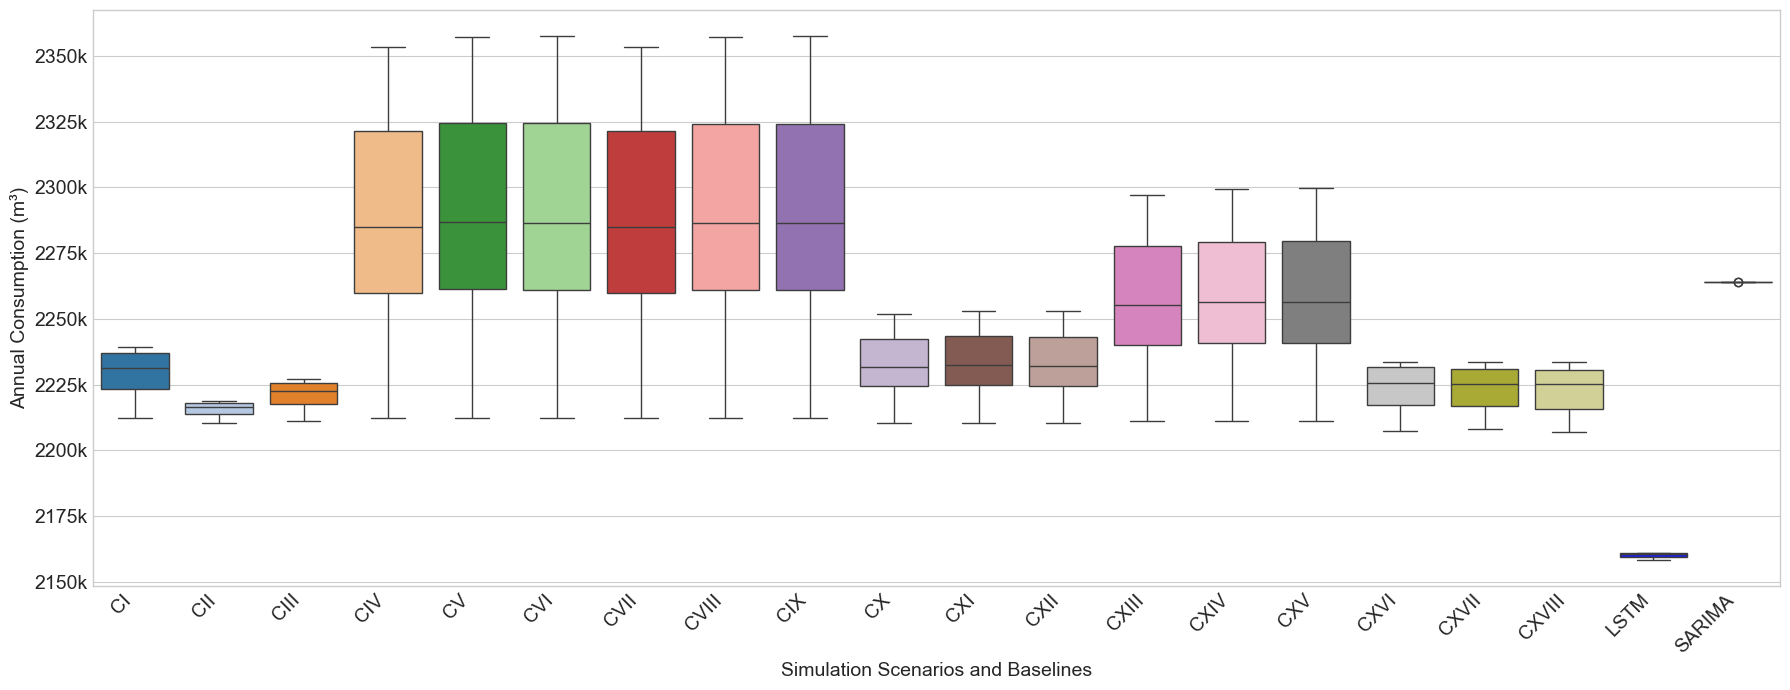

Boxplot saved: ..\figuras\figure-boxplot-comparison-scenarios-vs-lstm-sarima-fig12.pdf


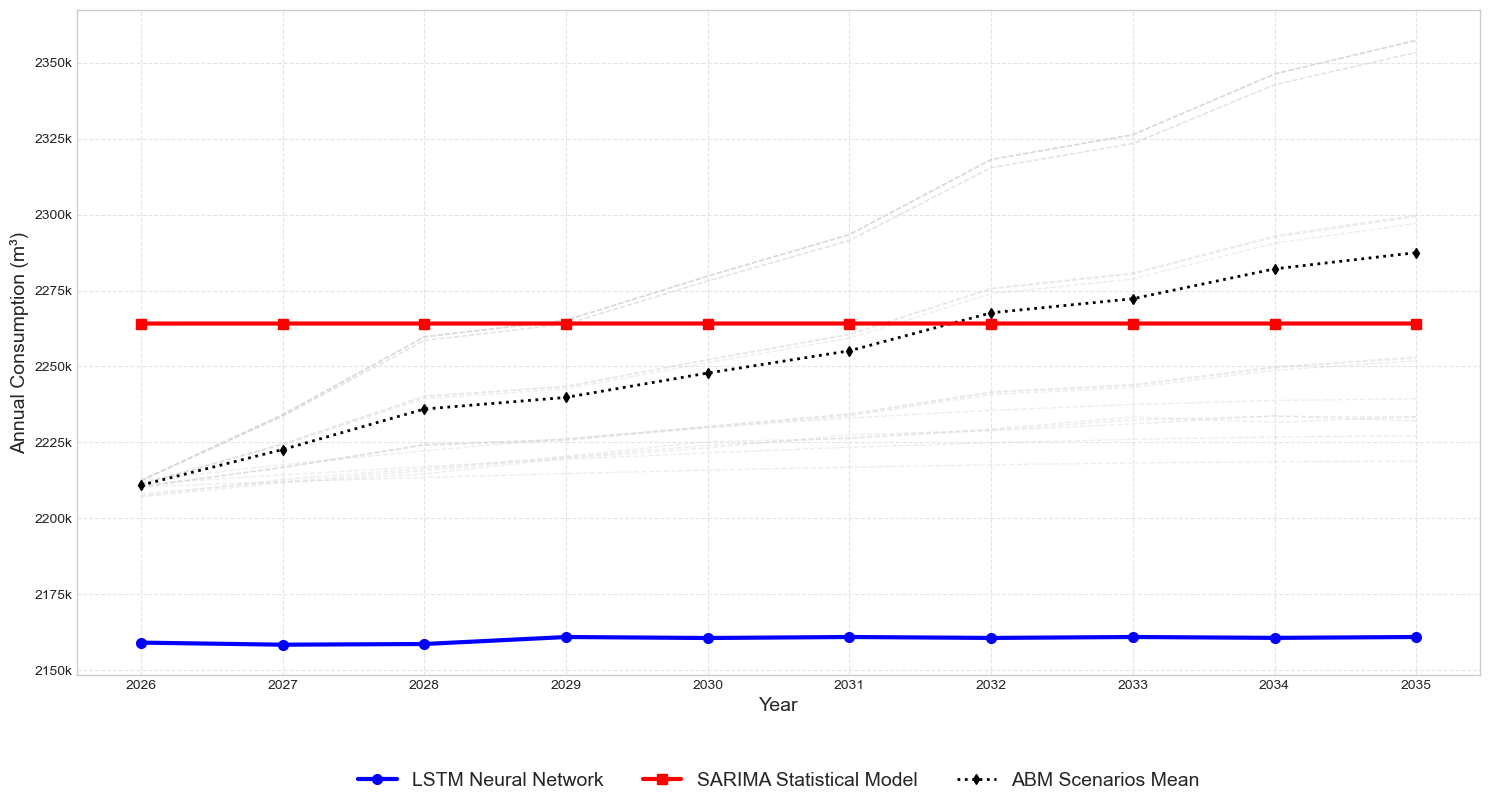

Time Series saved: ..\figuras\figure-chartline-comparison-scenarios-vs-lstm-sarima-fig12.pdf

SUMMARY STATISTICS (Annual Consumption 2026-2035)

LSTM Neural Network:
  Mean: 2160.1k m³
  Std: 1.0k m³
  Min: 2158.3k m³
  Max: 2160.9k m³

SARIMA Statistical Model:
  Mean: 2264.1k m³
  Std: 0.0k m³
  Min: 2264.1k m³
  Max: 2264.1k m³

ABM Scenarios (18 scenarios):
  Mean of all scenario means: 2252.2k m³
  Overall min across all scenarios: 2207.1k m³
  Overall max across all scenarios: 2357.5k m³

--- Analysis Complete ---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.ticker as mticker

from matplotlib.colors import to_rgba

# ==========================================
# 1. Configuration and Paths
# ==========================================

np.random.seed(42)

BASE_PATH = '..'

INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
LSTM_FILE = 'previsoes_futuras_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

FILE_BOXPLOT = 'figure-boxplot-comparison-scenarios-vs-lstm-sarima-fig12.pdf'
FILE_TIMESERIES = 'figure-chartline-comparison-scenarios-vs-lstm-sarima-fig12.pdf'

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('default')

sns.set_palette("husl")

def sum_yearly(df, date_col, value_cols):
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def roman_to_value(roman):
    """Convert Roman numeral to numeric value for proper sorting"""
    roman_values = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
        'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9, 'X': 10,
        'XI': 11, 'XII': 12, 'XIII': 13, 'XIV': 14, 'XV': 15,
        'XVI': 16, 'XVII': 17, 'XVIII': 18, 'XIX': 19, 'XX': 20
    }
    # Extract the Roman part after 'C'
    if roman.startswith('C'):
        roman_part = roman[1:]
        return roman_values.get(roman_part, 999)
    return 999

def main():
    print("--- Starting Descriptive Analysis: 18 Scenarios vs LSTM vs SARIMA ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
    
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[(df_scenarios['Date'] >= '2026-01-01') & (df_scenarios['Date'] <= '2035-12-31')]
    print(f"Scenarios loaded: {len(scenario_cols)} scenarios, {len(df_scenarios)} months")

    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, parse_dates=['Data'])
        df_lstm = df_lstm.rename(columns={'Data': 'Date', 'Valor Previsto': 'LSTM'})
        df_lstm = df_lstm[(df_lstm['Date'] >= '2026-01-01') & (df_lstm['Date'] <= '2035-12-31')]
        print(f"LSTM data loaded: {len(df_lstm)} months")
    else:
        print(f"Warning: LSTM file not found at {path_lstm}")
        df_lstm = None

    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        df_sarima = df_sarima.rename(columns={'Date': 'Date', 'Projected_Consumption': 'SARIMA'})
        df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
        df_sarima = df_sarima[(df_sarima['Date'] >= '2026-01-01') & (df_sarima['Date'] <= '2035-12-31')]
        print(f"SARIMA data loaded: {len(df_sarima)} months")
    else:
        print(f"Warning: SARIMA file not found at {path_sarima}")
        df_sarima = None

    df_combined = df_scenarios.copy()
    
    if df_lstm is not None:
        df_combined = pd.merge(df_combined, df_lstm[['Date', 'LSTM']], on='Date', how='left')
        all_series = scenario_cols + ['LSTM']
    
    if df_sarima is not None:
        df_combined = pd.merge(df_combined, df_sarima[['Date', 'SARIMA']], on='Date', how='left')
        all_series = scenario_cols + ['LSTM', 'SARIMA']
    
    df_annual = sum_yearly(df_combined, 'Date', all_series)
    
    short_names = {col: (col.split('_')[0] if '_' in col else col) for col in all_series}
    df_annual = df_annual.rename(columns=short_names)
    
    print(f"Annual data shape: {df_annual.shape}")
    print(f"Years analyzed: {df_annual['Year'].min()} - {df_annual['Year'].max()}")

    if not os.path.exists(INPUT_DIR_RES): 
        os.makedirs(INPUT_DIR_RES)
    
    stats_path = os.path.join(INPUT_DIR_RES, 'stats_summary_18_scenarios_vs_lstm_sarima.csv')
    df_annual.drop(columns='Year').describe().T.to_csv(stats_path)
    print(f"Statistics saved: {stats_path}")

    if not os.path.exists(OUTPUT_DIR): 
        os.makedirs(OUTPUT_DIR)

    # ==========================================
    # 4. Visualization 1: Boxplot
    # ==========================================
    plt.figure(figsize=(18, 7))
    df_melted = df_annual.melt(id_vars='Year', var_name='Scenario', value_name='Consumption')
    
    # order scenarios alpha
    all_scenarios = [c for c in df_annual.columns if c != 'Year']
    scenario_order = sorted(all_scenarios, key=roman_to_value)
    
    df_melted['Scenario'] = pd.Categorical(df_melted['Scenario'], categories=scenario_order, ordered=True)
    
    
    # color generate
    tab20_colors = [plt.cm.tab20(i) for i in range(20)]  # select 20 fixed colors
    color_map = {scenario: tab20_colors[i % 20] for i, scenario in enumerate(scenario_order)}
    color_map['LSTM'] = 'blue'
    color_map['SARIMA'] = 'red'
    

    ax1 = sns.boxplot(data=df_melted, x='Scenario', y='Consumption', palette=color_map, order=scenario_order)
    plt.ylabel('Annual Consumption (m³)', fontsize=14)
    plt.xlabel('Simulation Scenarios and Baselines', fontsize=14)
    
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
        # Set font size for y-axis tick labels
    for label in ax1.get_yticklabels():
        label.set_fontsize(14)
        
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.tight_layout()
    
    path_boxplot = os.path.join(OUTPUT_DIR, FILE_BOXPLOT)
    plt.savefig(path_boxplot, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Boxplot saved: {path_boxplot}")

    # ==========================================
    # 5. Visualization 2: Time Series
    # ==========================================
    plt.figure(figsize=(15, 8))
    
    for column in [c for c in df_annual.columns if c != 'Year' and c not in ['LSTM', 'SARIMA']]:
        plt.plot(df_annual['Year'], df_annual[column], linestyle='--', alpha=0.4, linewidth=1.0, color='lightgray')
    
    if 'LSTM' in df_annual.columns:
        plt.plot(df_annual['Year'], df_annual['LSTM'], label='LSTM Neural Network', 
                 color='blue', linewidth=3.0, marker='o', markersize=7, zorder=10)
    
    if 'SARIMA' in df_annual.columns:
        plt.plot(df_annual['Year'], df_annual['SARIMA'], label='SARIMA Statistical Model', 
                 color='red', linewidth=3.0, marker='s', markersize=7, zorder=10)
    
    scenario_cols_short = [c for c in df_annual.columns if c != 'Year' and c not in ['LSTM', 'SARIMA']]
    df_annual['Scenarios_Mean'] = df_annual[scenario_cols_short].mean(axis=1)
    plt.plot(df_annual['Year'], df_annual['Scenarios_Mean'], label='ABM Scenarios Mean', 
             color='black', linewidth=2.0, linestyle=':', marker='d', markersize=5, zorder=8)
    
    #plt.title('Evolution of Projected Annual Water Consumption (2026-2035)\n18 ABM Scenarios vs LSTM vs SARIMA', 
    #          fontsize=14)
    plt.ylabel('Annual Consumption (m³)', fontsize=14)
    plt.xlabel('Year', fontsize=14)
    
    ax2 = plt.gca()
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, shadow=True, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    path_timeseries = os.path.join(OUTPUT_DIR, FILE_TIMESERIES)
    plt.savefig(path_timeseries, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Time Series saved: {path_timeseries}")
    
    print("\n" + "="*60)
    print("SUMMARY STATISTICS (Annual Consumption 2026-2035)")
    print("="*60)
    
    if 'LSTM' in df_annual.columns:
        print(f"\nLSTM Neural Network:")
        print(f"  Mean: {df_annual['LSTM'].mean()/1000:.1f}k m³")
        print(f"  Std: {df_annual['LSTM'].std()/1000:.1f}k m³")
        print(f"  Min: {df_annual['LSTM'].min()/1000:.1f}k m³")
        print(f"  Max: {df_annual['LSTM'].max()/1000:.1f}k m³")
    
    if 'SARIMA' in df_annual.columns:
        print(f"\nSARIMA Statistical Model:")
        print(f"  Mean: {df_annual['SARIMA'].mean()/1000:.1f}k m³")
        print(f"  Std: {df_annual['SARIMA'].std()/1000:.1f}k m³")
        print(f"  Min: {df_annual['SARIMA'].min()/1000:.1f}k m³")
        print(f"  Max: {df_annual['SARIMA'].max()/1000:.1f}k m³")
    
    abm_values = []
    for col in scenario_cols_short:
        abm_values.extend(df_annual[col].values)
    print(f"\nABM Scenarios ({len(scenario_cols_short)} scenarios):")
    print(f"  Mean of all scenario means: {np.mean([df_annual[col].mean() for col in scenario_cols_short])/1000:.1f}k m³")
    print(f"  Overall min across all scenarios: {np.min(abm_values)/1000:.1f}k m³")
    print(f"  Overall max across all scenarios: {np.max(abm_values)/1000:.1f}k m³")
    
    print("\n--- Analysis Complete ---")

if __name__ == "__main__":
    main()